# Comparing Data Sets.
____

In [44]:
from pathlib import Path
from microlive.imports import *
from microlive import microscopy as mi
current_dir = Path().resolve()
parent_dir = current_dir.parents[1]
main_dir = Path().resolve().parent
one_drive_dir = mi.Utilities.get_one_drive_dir()
import sys
repo_root = Path().resolve().parents[1]  # Go up to cof_paper/
sys.path.insert(0, str(repo_root))

import utilities as ld
importlib.reload(ld)


<module 'utilities' from 'C:\\Users\\searsrh\\OneDrive - The University of Colorado Denver\\Desktop\\cof_paper\\utilities\\__init__.py'>

## Loading data and strings for subclassification
___

In [45]:
# Loading data
        #RMS External Drive Location:    'E:/Co-translational folding (CoF) paper/Fig 2_Slow coTFT minitrack analysis'
        #Ning Zhao OneDrive Location:    '...General - Zhao (NZ) Lab\Zhao lab shared folder\Our papers\co-translational folding paper\Fig 2\Fig 2_Slow coTFT minitrack analysis'
dataframes_dir = Path('E:/Co-translational folding (CoF) paper/Fig 2_Slow coTFT minitrack analysis')

# Average Folder Substrings

list_folder_substring_to_avoid = None


save_dir = current_dir.joinpath('results_Fig2_slow')
save_dir.mkdir(parents=True, exist_ok=True)

# Individual day Folder Substrings
plot_individual_days = False    # Set to False to skip plotting individual experiment days and plot the overall average.

list_folder_substrings, list_names = ld.get_folder_substrings_and_names(
    dataframes_dir, 
    process_individual_days=plot_individual_days,
)
print(list_folder_substrings)
print(list_names)


Found 5 plasmids in 171 folders
  pRS032: 4 experiment(s)
  pNZ370: 3 experiment(s)
  pNZ388: 3 experiment(s)
  pNZ389: 3 experiment(s)
  pNZ396: 2 experiment(s)
['pNZ370', 'pRS032', 'pNZ396', 'pNZ389', 'pNZ388']
['6GFPuv', '4GFPuv-2mCh', '3GFPuv-3mCh', '2GFPuv-4mCh', '1GFPuv-5mCh']


In [74]:
#rearrange the data in the graphs

list_folder_substrings = ['pNZ388', 'pNZ389', 'pNZ396', 'pRS032', 'pNZ370']
list_names = ['1GFPuv-5mCh', '2GFPuv-4mCh', '3GFPuv-3mCh', '4GFPuv-2mCh', '6GFPuv']

## Loading the data
____

In [75]:
data_dict = ld.aggregate_folder_data(dataframes_dir,list_folder_substrings,
            list_folder_substring_to_avoid,list_folder_substring_second_condition=None,
            show_file_names=True, verbose= False)

Loaded results_20260115 pNZ388_pRS012_JF646 6hr Tfx_Series001 (2 channels)
Loaded results_20260123 pNZ388_pRS012_JF646 6hr Tfx_Series003 (2 channels)
Loaded results_20260115 pNZ388_pRS012_JF646 6hr Tfx_Series003 (2 channels)
Loaded results_20260123 pNZ388_pRS012_JF646 6hr Tfx_Series004 (2 channels)
Loaded results_20260115 pNZ388_pRS012_JF646 6hr Tfx_Series004 (2 channels)
Loaded results_20260123 pNZ388_pRS012_JF646 6hr Tfx_Series005 (2 channels)
Loaded results_20260115 pNZ388_pRS012_JF646 6hr Tfx_Series005 (2 channels)
Loaded results_20260123 pNZ388_pRS012_JF646 6hr Tfx_Series006 (2 channels)
Loaded results_20260115 pNZ388_pRS012_JF646 6hr Tfx_Series006 (2 channels)
Loaded results_20260123 pNZ388_pRS012_JF646 6hr Tfx_Series007 (2 channels)
Loaded results_20260123 pNZ388_pRS012_JF646 6hr Tfx_Series008 (2 channels)
Loaded results_20260115 pNZ388_pRS012_JF646 6hr Tfx_Series008 (2 channels)
Loaded results_20260123 pNZ388_pRS012_JF646 6hr Tfx_Series009 (2 channels)
Loaded results_20260115 p

## Plotting Configuration
___

In [76]:
# ── Plotting Configuration ─────────────────────────────────
PLOT_CONFIG = dict(
    figsize       = (6.7, 5),
    tick_size     = 10,
    swarm_color   = 'black',
    show_stats    = False,
    only_significant = True,
    max_percentile_significance = 99.5,
)

SAVE_DIR = save_dir  # Defined in data config above; set to None to skip saving


## Plotting data
___

In [77]:
for key in data_dict.keys():
    print(key)


directories
int_ch_0
int_ch_1
snr_ch_0
snr_ch_1
spot_size_ch_0
spot_size_ch_1
total_spot_int_ch_0
total_spot_int_ch_1
spot_amplitude_ch_0
spot_amplitude_ch_1
spot_sigma_ch_0
spot_sigma_ch_1
number_spots
frames
number_of_color_channels
average_number_spots
efficiency_ml
efficiency_manual


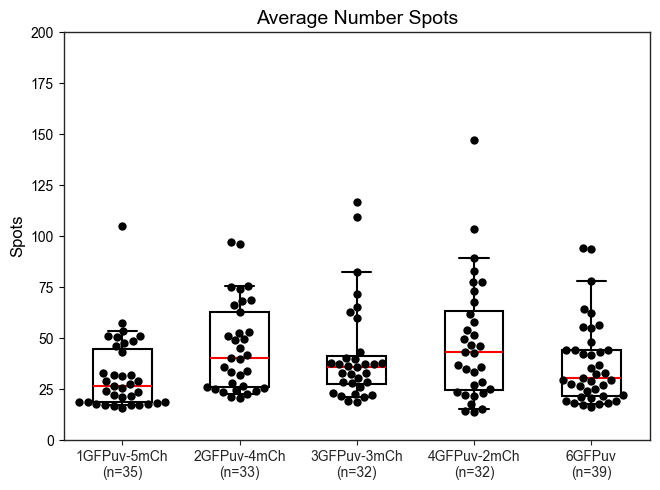

<Axes: title={'center': 'Average Number Spots'}, ylabel='Spots'>

In [78]:
ld.plot_swarm_plot(
    data_dict['average_number_spots'], list_names,
    y_label='Spots',
    title='Average Number Spots',
    y_lim=(0, 200),
    plot_name='avg_spots',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


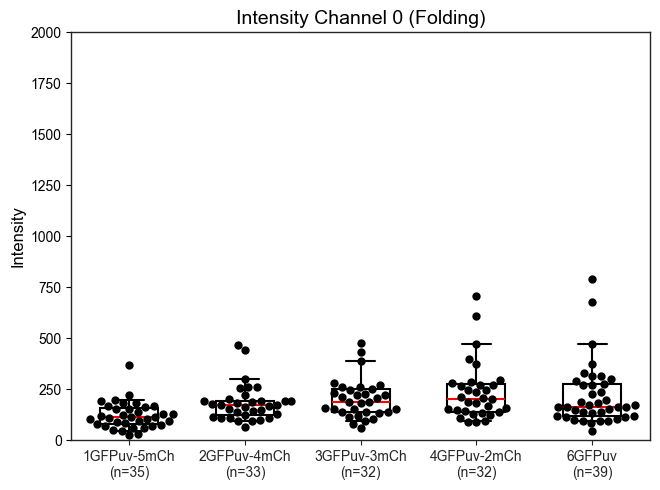

<Axes: title={'center': 'Intensity Channel 0 (Folding)'}, ylabel='Intensity'>

In [79]:
ld.plot_swarm_plot(
    data_dict['int_ch_0'], list_names,
    y_label='Intensity',
    title='Intensity Channel 0 (Folding)',
    y_lim=(0, 2000),
    plot_name='int_ch0',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


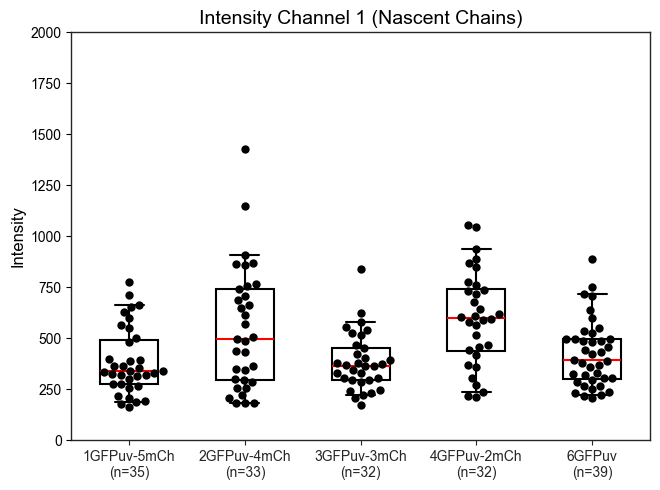

<Axes: title={'center': 'Intensity Channel 1 (Nascent Chains)'}, ylabel='Intensity'>

In [80]:
ld.plot_swarm_plot(
    data_dict['int_ch_1'], list_names,
    y_label='Intensity',
    title='Intensity Channel 1 (Nascent Chains)',
    y_lim=(0, 2000),
    plot_name='int_ch1',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


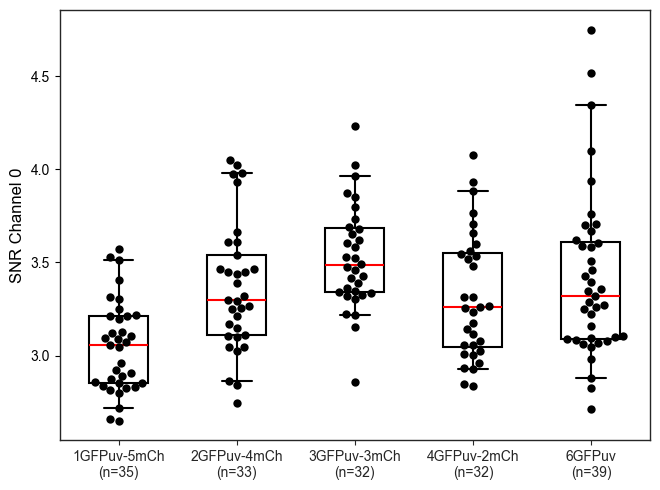

<Axes: ylabel='SNR Channel 0'>

In [81]:
ld.plot_swarm_plot(
    data_dict['snr_ch_0'], list_names,
    y_label='SNR Channel 0',
    plot_name='snr_ch0',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


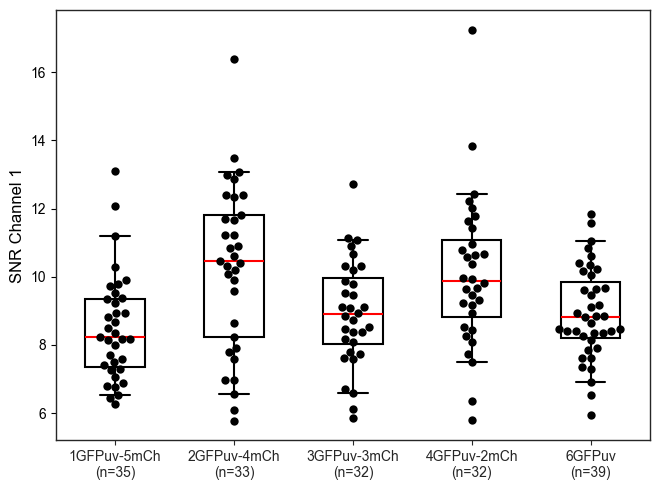

<Axes: ylabel='SNR Channel 1'>

In [82]:
ld.plot_swarm_plot(
    data_dict['snr_ch_1'], list_names,
    y_label='SNR Channel 1',
    plot_name='snr_ch1',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


## Calculating Folding Efficiency using ML method

___

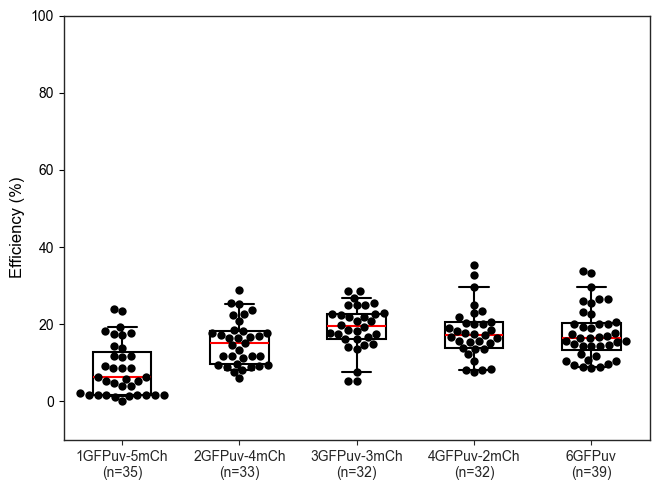

<Axes: ylabel='Efficiency (%)'>

In [87]:
ld.plot_swarm_plot(
    data_dict['efficiency_ml'], list_names,
    y_label='Efficiency (%)',
    y_lim=(-10, 100),
    plot_name='efficiency_ml',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


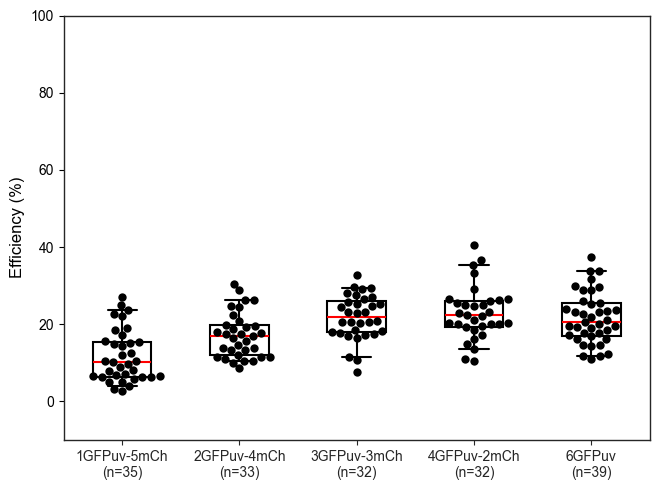

<Axes: ylabel='Efficiency (%)'>

In [88]:
ld.plot_swarm_plot(
    data_dict['efficiency_manual'], list_names,
    y_label='Efficiency (%)',
    y_lim=(-10, 100),
    plot_name='efficiency_verification',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


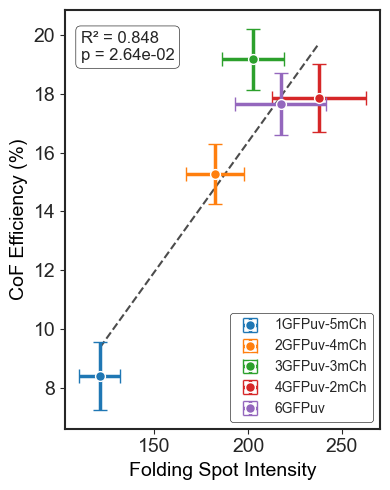

<Axes: xlabel='Folding Spot Intensity', ylabel='CoF Efficiency (%)'>

In [89]:
ld.plot_efficiency_vs_intensity_scatter_means(
    data_dict, list_names,
    x_label='Folding Spot Intensity',
    y_label='CoF Efficiency (%)',
    #figsize=PLOT_CONFIG['figsize'], figsize= (3.75, 4.5),
    figsize= (4, 5),
    tick_size=PLOT_CONFIG['tick_size'],
    marker_size=50,
    save_dir=SAVE_DIR,
    plot_name='intensity_efficiency',
    show_legend=True,
)


In [90]:
SAVE_DIR

WindowsPath('C:/Users/searsrh/OneDrive - The University of Colorado Denver/Desktop/cof_paper/notebooks/CoF_project/results_Fig2_slow')